# Rolex Watch Price Analysis - Part 1: Data Preparation
## Final Project - Data Analytics

## Libraries and settings

In [28]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## 1. Data Collection

The data was collected using web scraping from Chrono24.com, one of the world's largest marketplaces for luxury watches. Chrono24 connects private sellers and professional dealers globally, offering a comprehensive view of the Rolex watch market.

The scraping process captured:
- Watch specifications (model, reference number, materials)
- Pricing information
- Condition and documentation details
- Seller information
- Geographic location data

## 2. Import Raw Data

In [29]:
df_raw = pd.read_csv('chrono.csv', encoding='utf-8')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")

Dataset shape: (2400, 19)

Column names:
 1. web_scraper_order
 2. web_scraper_start_url
 3. watch
 4. watch-href
 5. name_raw
 6. listing_code_raw
 7. brand_raw
 8. reference_number_raw
 9. model_raw
10. movement_raw
11. condition_raw
12. scope_of_delivery_raw
13. seller_type
14. case_material
15. production_year
16. location_raw
17. price_raw
18. bracelet_material
19. description


In [30]:
df_raw.head(10)

,web_scraper_order,web_scraper_start_url,watch,watch-href,name_raw,listing_code_raw,brand_raw,reference_number_raw,model_raw,movement_raw,condition_raw,scope_of_delivery_raw,seller_type,case_material,production_year,location_raw,price_raw,bracelet_material,description
0,1766787539-1,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex GMT-Master II\n \n\n \n ...,https://www.chrono24.com/rolex/gmt-master-ii--...,Popular,QBJ2I7,Rolex,126715CHNR\n \n ...,GMT-Master II,Automatic,Used (Very good)\n \n ...,"No original box, no original papers",Professional dealer,Red gold,Unknown,"United States of America, Katy",Price on request,Rose gold,Rolex 126715 “Rootbeer “ Solid Gold \n\n\n\nWa...
1,1766787541-2,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Datejust 31\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-datejust-...,NaN,QBJ2M8,Rolex,278274,Datejust 31,Automatic,New\n \n ...,"Original box, original papers",Professional dealer,Steel,2023,"Netherlands, Franeker","CHF11,415",Steel,NaN
2,1766787544-3,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Cellini Danaos\n \n\n \n ...,https://www.chrono24.com/rolex/cellini-danaos-...,NaN,QBJ309,Rolex,4233,Cellini Danaos,Manual winding,Used (Fair)\n \n ...,"No original box, no original papers",Professional dealer,Rose gold,2010,"United States of America, New York City","CHF5,248",NaN,Rolex Cellini Danaos Ref. 4233 \n\n2 tone rose...
3,1766787546-4,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex GMT-Master II\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-gmt-maste...,Popular,QBJ335,Rolex,126720VTNR,GMT-Master II,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Partner Certified Included,Steel,2024,"Netherlands, Franeker","CHF14,745",Steel,NaN
4,1766787548-5,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Sea-Dweller\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-1665-grea...,NaN,QBJ3J3,Rolex,1665\n \n ...,Sea-Dweller,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Professional dealer,Steel,1979 (Approximation),"United States of America, Colorado, Boulder","CHF23,009",Steel,A 'Rail Dial' ref. 1665 'Great White' Sea-Dwel...
5,1766787550-6,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Explorer\n \n\n \n 124...,https://www.chrono24.com/rolex/rolex-explorer-...,NaN,QBJ3O3,Rolex,124270\n \n ...,Explorer,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Partner Certified Included,Steel,2022,"Netherlands, Franeker","CHF7,132",Steel,NaN
6,1766787552-7,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Cellini Danaos\n \n\n \n ...,https://www.chrono24.com/rolex/cellini-danaos-...,NaN,QBJ3V0,Rolex,4233\n \n ...,Cellini Danaos,Manual winding,Used (Fair)\n \n ...,"No original box, no original papers",Professional dealer,White gold,2010,"United States of America, New York City","CHF5,248",NaN,NaN
7,1766787554-8,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Oyster Perpetual 41\n \n\n \n ...,https://www.chrono24.com/rolex/124300-oyster-p...,Popular,QBJ452,Rolex,124300,Oyster Perpetual 41,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Partner Certified Included,Steel,Unknown,"United States of America, Massachusetts, Boston","CHF8,800",Steel,The Rolex 124300 Oyster Perpetual SS Green Dia...
8,1766787556-9,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Daytona\n \n\n \n 1165...,https://www.chrono24.com/rolex/116503-daytona-...,Popular,QBJ488,Rolex,116503,Daytona,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Partner Certified Included,Yellow gold and steel,Unknown,"United States of America, Massachusetts, Boston","CHF19,295",NaN,The Rolex 116503 Daytona Black Dial Two Tone i...
9,1766787558-10,https://www.chrono24.com/rolex/index-20.htm?pa...,Rolex Submariner Date\n \n\n \n ...,https://www.chrono24.com/rolex/1680-submariner...,Popular\n\nPopular\n\nPopular,QBJ490,Rolex,1680\n \n ...,Submariner Date,Automatic,Used (Very good)\n \n ...,"

## 3. Initial Data Exploration

In [31]:
print("Data types:")
print(df_raw.dtypes)
print("\n" + "="*60)
print("\nMissing values:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

Data types:
web_scraper_order        object
web_scraper_start_url    object
watch                    object
watch-href               object
name_raw                 object
listing_code_raw         object
brand_raw                object
reference_number_raw     object
model_raw                object
movement_raw             object
condition_raw            object
scope_of_delivery_raw    object
seller_type              object
case_material            object
production_year          object
location_raw             object
price_raw                object
bracelet_material        object
description              object
dtype: object


Missing values:
                      Missing  Percentage
name_raw                 1065       44.38
bracelet_material         468       19.50
movement_raw              245       10.21
case_material             244       10.17
description               178        7.42
condition_raw             163        6.79
reference_number_raw       30        1.25
model_raw   

In [32]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      2400 non-null   object
 1   web_scraper_start_url  2400 non-null   object
 2   watch                  2400 non-null   object
 3   watch-href             2400 non-null   object
 4   name_raw               1335 non-null   object
 5   listing_code_raw       2400 non-null   object
 6   brand_raw              2400 non-null   object
 7   reference_number_raw   2370 non-null   object
 8   model_raw              2375 non-null   object
 9   movement_raw           2155 non-null   object
 10  condition_raw          2237 non-null   object
 11  scope_of_delivery_raw  2400 non-null   object
 12  seller_type            2400 non-null   object
 13  case_material          2156 non-null   object
 14  production_year        2400 non-null   object
 15  location_raw         

In [33]:
print("Sample of raw price values:")
print(df_raw['price_raw'].head(20))

Sample of raw price values:
0     Price on request
1            CHF11,415
2             CHF5,248
3            CHF14,745
4            CHF23,009
5             CHF7,132
6             CHF5,248
7             CHF8,800
8            CHF19,295
9            CHF10,899
10           CHF16,066
11            CHF9,284
12           CHF11,222
13           CHF14,451
14            CHF6,657
15           CHF10,230
16           CHF16,065
17           CHF12,609
18           CHF19,376
19            CHF9,062
Name: price_raw, dtype: object


## 4. Data Cleaning and Feature Engineering

### 4.1 Extract Numeric Price from price_raw

In [34]:
def extract_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    numbers = re.findall(r'[\d,]+', price_str)
    if numbers:
        price = numbers[0].replace(',', '')
        try:
            return float(price)
        except:
            return np.nan
    return np.nan

df_raw['price'] = df_raw['price_raw'].apply(extract_price)

print(f"Price extraction results:")
print(f"  Successfully extracted: {df_raw['price'].notna().sum():,} prices")
print(f"  Failed to extract: {df_raw['price'].isna().sum():,} prices")
print(f"\nPrice statistics:")
print(f"  Minimum: {df_raw['price'].min():,.2f} CHF")
print(f"  Maximum: {df_raw['price'].max():,.2f} CHF")
print(f"  Mean: {df_raw['price'].mean():,.2f} CHF")
print(f"  Median: {df_raw['price'].median():,.2f} CHF")

Price extraction results:
  Successfully extracted: 2,374 prices
  Failed to extract: 26 prices

Price statistics:
  Minimum: 868.00 CHF
  Maximum: 205,626.00 CHF
  Mean: 13,980.21 CHF
  Median: 10,539.50 CHF


### 4.2 Extract Production Year

In [35]:
def extract_year(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str)
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', year_str)
    if years:
        year = int(years[0])
        if 1900 <= year <= 2024:
            return year
    return np.nan

df_raw['year'] = df_raw['production_year'].apply(extract_year)

print(f"Year extraction results:")
print(f"  Successfully extracted: {df_raw['year'].notna().sum():,} years")
print(f"  Failed to extract: {df_raw['year'].isna().sum():,} years")
print(f"\nYear statistics:")
print(f"  Earliest: {df_raw['year'].min():.0f}")
print(f"  Latest: {df_raw['year'].max():.0f}")
print(f"  Mean: {df_raw['year'].mean():.0f}")
print(f"  Median: {df_raw['year'].median():.0f}")

Year extraction results:
  Successfully extracted: 1,189 years
  Failed to extract: 1,211 years

Year statistics:
  Earliest: 1942
  Latest: 2024
  Mean: 2010
  Median: 2015


### 4.3 Calculate Watch Age

In [36]:
current_year = 2024
df_raw['age'] = current_year - df_raw['year']
df_raw['age'] = df_raw['age'].apply(lambda x: x if pd.notna(x) and 0 <= x <= 100 else np.nan)

print(f"Age statistics:")
print(f"  Minimum age: {df_raw['age'].min():.0f} years")
print(f"  Maximum age: {df_raw['age'].max():.0f} years")
print(f"  Average age: {df_raw['age'].mean():.1f} years")
print(f"  Median age: {df_raw['age'].median():.0f} years")

Age statistics:
  Minimum age: 0 years
  Maximum age: 82 years
  Average age: 14.4 years
  Median age: 9 years


### 4.4 Categorize Watch Condition

In [37]:
def categorize_condition(condition_str):
    if pd.isna(condition_str):
        return 'Unknown'
    condition_str = str(condition_str).lower()
    if 'new' in condition_str or 'unworn' in condition_str:
        return 'New'
    elif 'very good' in condition_str:
        return 'Very Good'
    elif 'good' in condition_str:
        return 'Good'
    elif 'fair' in condition_str:
        return 'Fair'
    elif 'incomplete' in condition_str or 'not functional' in condition_str:
        return 'Incomplete'
    else:
        return 'Used'

df_raw['condition_category'] = df_raw['condition_raw'].apply(categorize_condition)

print("Condition distribution:")
print(df_raw['condition_category'].value_counts())
print(f"\nPercentage distribution:")
print((df_raw['condition_category'].value_counts() / len(df_raw) * 100).round(2))

Condition distribution:
condition_category
Very Good    1268
Good          500
New           350
Unknown       163
Fair          119
Name: count, dtype: int64

Percentage distribution:
condition_category
Very Good    52.83
Good         20.83
New          14.58
Unknown       6.79
Fair          4.96
Name: count, dtype: float64


### 4.5 Extract Geographic Information

In [38]:
def extract_country(location_str):
    if pd.isna(location_str):
        return 'Unknown'
    location_str = str(location_str).strip()
    parts = location_str.split(',')
    if len(parts) >= 1:
        return parts[0].strip()
    return 'Unknown'

def extract_city(location_str):
    if pd.isna(location_str):
        return 'Unknown'
    location_str = str(location_str).strip()
    parts = location_str.split(',')
    if len(parts) >= 2:
        return parts[1].strip()
    return 'Unknown'

df_raw['country'] = df_raw['location_raw'].apply(extract_country)
df_raw['city'] = df_raw['location_raw'].apply(extract_city)

print("Top 15 countries:")
print(df_raw['country'].value_counts().head(15))
print(f"\nTotal unique countries: {df_raw['country'].nunique()}")

Top 15 countries:
country
United States of America    946
Japan                       759
Italy                       101
Germany                      97
Netherlands                  94
United Kingdom               87
Hong Kong                    79
Spain                        41
France                       37
Belgium                      26
Sweden                       20
UAE                          19
Switzerland                  10
Canada                        9
Singapore                     9
Name: count, dtype: int64

Total unique countries: 35


### 4.6 Create Binary Features for Documentation

In [39]:
df_raw['has_box'] = df_raw['scope_of_delivery_raw'].fillna('').str.lower().str.contains('box').astype(int)
df_raw['has_papers'] = df_raw['scope_of_delivery_raw'].fillna('').str.lower().str.contains('paper').astype(int)
df_raw['has_complete_set'] = ((df_raw['has_box'] == 1) & (df_raw['has_papers'] == 1)).astype(int)

print(f"Documentation statistics:")
print(f"  Watches with box: {df_raw['has_box'].sum():,} ({df_raw['has_box'].mean()*100:.1f}%)")
print(f"  Watches with papers: {df_raw['has_papers'].sum():,} ({df_raw['has_papers'].mean()*100:.1f}%)")
print(f"  Watches with complete set: {df_raw['has_complete_set'].sum():,} ({df_raw['has_complete_set'].mean()*100:.1f}%)")

Documentation statistics:
  Watches with box: 2,400 (100.0%)
  Watches with papers: 2,400 (100.0%)
  Watches with complete set: 2,400 (100.0%)


### 4.7 Create Seller Type Binary Variable

In [40]:
df_raw['is_professional'] = (df_raw['seller_type'] == 'Professional dealer').astype(int)

print("Seller type distribution:")
print(df_raw['seller_type'].value_counts())
print(f"\nProfessional dealers: {df_raw['is_professional'].sum():,} ({df_raw['is_professional'].mean()*100:.1f}%)")

Seller type distribution:
seller_type
Professional dealer           1630
Partner Certified Included     694
Private Seller                  76
Name: count, dtype: int64

Professional dealers: 1,630 (67.9%)


### 4.8 Extract and Clean Material Information

In [41]:
def clean_material(material_str):
    if pd.isna(material_str):
        return 'Unknown'
    material_str = str(material_str).strip()
    if material_str == '':
        return 'Unknown'
    return material_str

df_raw['case_material_clean'] = df_raw['case_material'].apply(clean_material)
df_raw['bracelet_material_clean'] = df_raw['bracelet_material'].apply(clean_material)

print("Top 10 case materials:")
print(df_raw['case_material_clean'].value_counts().head(10))
print("\nTop 10 bracelet materials:")
print(df_raw['bracelet_material_clean'].value_counts().head(10))

Top 10 case materials:
case_material_clean
Steel                    1466
Unknown                   244
Gold/Steel                224
Yellow gold               199
Rose gold                  86
White gold                 77
Yellow gold and steel      53
White gold and steel       18
Platinum                   14
Rose gold and steel        10
Name: count, dtype: int64

Top 10 bracelet materials:
bracelet_material_clean
Steel             1131
Unknown            468
Gold/Steel         272
Yellow gold        260
Rose gold           89
Leather             53
White gold          50
Rubber              49
Platinum            16
Crocodile skin       4
Name: count, dtype: int64


### 4.9 Create Material Category Features

In [42]:
def categorize_material(material_str):
    if pd.isna(material_str):
        return 'Unknown'
    material_str = str(material_str).lower()
    
    if 'gold' in material_str and 'steel' in material_str:
        return 'Gold/Steel'
    elif 'yellow gold' in material_str or 'gold (solid)' in material_str:
        return 'Yellow Gold'
    elif 'white gold' in material_str:
        return 'White Gold'
    elif 'rose gold' in material_str or 'pink gold' in material_str:
        return 'Rose Gold'
    elif 'platinum' in material_str:
        return 'Platinum'
    elif 'steel' in material_str:
        return 'Steel'
    else:
        return 'Other'

df_raw['material_category'] = df_raw['case_material_clean'].apply(categorize_material)

print("Material category distribution:")
print(df_raw['material_category'].value_counts())

Material category distribution:
material_category
Steel          1466
Gold/Steel      305
Other           253
Yellow Gold     199
Rose Gold        86
White Gold       77
Platinum         14
Name: count, dtype: int64


### 4.10 Extract Movement Type

In [43]:
def categorize_movement(movement_str):
    if pd.isna(movement_str):
        return 'Unknown'
    movement_str = str(movement_str).lower()
    
    if 'automatic' in movement_str:
        return 'Automatic'
    elif 'manual' in movement_str or 'hand' in movement_str:
        return 'Manual'
    elif 'quartz' in movement_str:
        return 'Quartz'
    else:
        return 'Unknown'

df_raw['movement_type'] = df_raw['movement_raw'].apply(categorize_movement)

print("Movement type distribution:")
print(df_raw['movement_type'].value_counts())

Movement type distribution:
movement_type
Automatic    2118
Unknown       245
Manual         32
Quartz          5
Name: count, dtype: int64


## 5. Select Final Columns and Clean Dataset

In [44]:
columns_final = [
    'web_scraper_order',
    'brand_raw',
    'model_raw',
    'reference_number_raw',
    'movement_type',
    'condition_category',
    'seller_type',
    'case_material_clean',
    'bracelet_material_clean',
    'material_category',
    'country',
    'city',
    'price',
    'year',
    'age',
    'has_box',
    'has_papers',
    'has_complete_set',
    'is_professional'
]

df_clean = df_raw[columns_final].copy()

print(f"Dataset after column selection: {df_clean.shape}")

Dataset after column selection: (2400, 19)


### Remove records with missing price

In [45]:
print(f"Records before removing missing prices: {len(df_clean):,}")
df_clean = df_clean.dropna(subset=['price'])
print(f"Records after removing missing prices: {len(df_clean):,}")
print(f"Records removed: {len(df_raw) - len(df_clean):,}")

Records before removing missing prices: 2,400
Records after removing missing prices: 2,374
Records removed: 26


### Filter price outliers

In [46]:
print(f"Records before filtering outliers: {len(df_clean):,}")
df_clean = df_clean[(df_clean['price'] >= 1000) & (df_clean['price'] <= 500000)]
print(f"Records after filtering outliers: {len(df_clean):,}")
print(f"\nPrice range after filtering:")
print(f"  Minimum: {df_clean['price'].min():,.2f} CHF")
print(f"  Maximum: {df_clean['price'].max():,.2f} CHF")
print(f"  Mean: {df_clean['price'].mean():,.2f} CHF")
print(f"  Median: {df_clean['price'].median():,.2f} CHF")

Records before filtering outliers: 2,374
Records after filtering outliers: 2,373

Price range after filtering:
  Minimum: 1,294.00 CHF
  Maximum: 205,626.00 CHF
  Mean: 13,985.74 CHF
  Median: 10,559.00 CHF


### Remove duplicates

In [47]:
print(f"Records before removing duplicates: {len(df_clean):,}")
df_clean = df_clean.drop_duplicates()
print(f"Records after removing duplicates: {len(df_clean):,}")

Records before removing duplicates: 2,373
Records after removing duplicates: 2,373


## 6. Final Dataset Summary

In [48]:
print("="*70)
print("FINAL DATASET SUMMARY")
print("="*70)
print(f"\nDataset shape: {df_clean.shape}")
print(f"  - {df_clean.shape[0]:,} records")
print(f"  - {df_clean.shape[1]} features")
print(f"\nMissing values in final dataset:")
missing_final = df_clean.isnull().sum()
missing_pct_final = (missing_final / len(df_clean) * 100).round(2)
missing_df_final = pd.DataFrame({
    'Missing': missing_final,
    'Percentage': missing_pct_final
})
print(missing_df_final[missing_df_final['Missing'] > 0].sort_values('Missing', ascending=False))

FINAL DATASET SUMMARY

Dataset shape: (2373, 19)
  - 2,373 records
  - 19 features

Missing values in final dataset:
                      Missing  Percentage
year                     1199       50.53
age                      1199       50.53
reference_number_raw       30        1.26
model_raw                  24        1.01


In [49]:
df_clean.head(10)

,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
1,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
2,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
3,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
4,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
5,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0
6,1766787552-7,Rolex,Cellini Danaos,4233\n \n ...,Manual,Fair,Professional dealer,White gold,Unknown,White Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
7,1766787554-8,Rolex,Oyster Perpetual 41,124300,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,United States of America,Massachusetts,8800.0,NaN,NaN,1,1,1,0
8,1766787556-9,Rolex,Daytona,116503,Automatic,Very Good,Partner Certified Included,Yellow gold and steel,Unknown,Gold/Steel,United States of America,Massachusetts,19295.0,NaN,NaN,1,1,1,0
9,1766787558-10,Rolex,Submariner Date,1680\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Unknown,Steel,United States of America,Massachusetts,10899.0,NaN,NaN,1,1,1,0
10,1766787560-11,Rolex,Day-Date 36,18239,Automatic,Very Good,Partner Certified Included,White gold,Unknown,White Gold,United States of America,Massachusetts,16066.0,NaN,NaN,1,1,1,0


In [50]:
df_clean.describe()

,price,year,age,has_box,has_papers,has_complete_set,is_professional
count,2373.000000,1174.000000,1174.000000,2373.0,2373.0,2373.0,2373.000000
mean,13985.739149,2009.688245,14.311755,1.0,1.0,1.0,0.675516
std,13679.298647,15.535837,15.535837,0.0,0.0,0.0,0.468280
min,1294.000000,1942.000000,0.000000,1.0,1.0,1.0,0.000000
25%,6842.000000,2001.000000,2.000000,1.0,1.0,1.0,0.000000
50%,10559.000000,2015.000000,9.000000,1.0,1.0,1.0,1.000000
75%,15541.000000,2022.000000,23.000000,1.0,1.0,1.0,1.000000
max,205626.000000,2024.000000,82.000000,1.0,1.0,1.0,1.000000


In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2373 entries, 1 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   web_scraper_order        2373 non-null   object 
 1   brand_raw                2373 non-null   object 
 2   model_raw                2349 non-null   object 
 3   reference_number_raw     2343 non-null   object 
 4   movement_type            2373 non-null   object 
 5   condition_category       2373 non-null   object 
 6   seller_type              2373 non-null   object 
 7   case_material_clean      2373 non-null   object 
 8   bracelet_material_clean  2373 non-null   object 
 9   material_category        2373 non-null   object 
 10  country                  2373 non-null   object 
 11  city                     2373 non-null   object 
 12  price                    2373 non-null   float64
 13  year                     1174 non-null   float64
 14  age                      1174

## 7. Save Cleaned Dataset

In [52]:
output_file = 'rolex_data_cleaned.csv'
df_clean.to_csv(output_file, index=False, encoding='utf-8')
print(f"Cleaned dataset saved to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1024 / 1024:.2f} MB")

Cleaned dataset saved to: rolex_data_cleaned.csv
File size: 0.39 MB


## 8. Quick Visualization of Key Variables

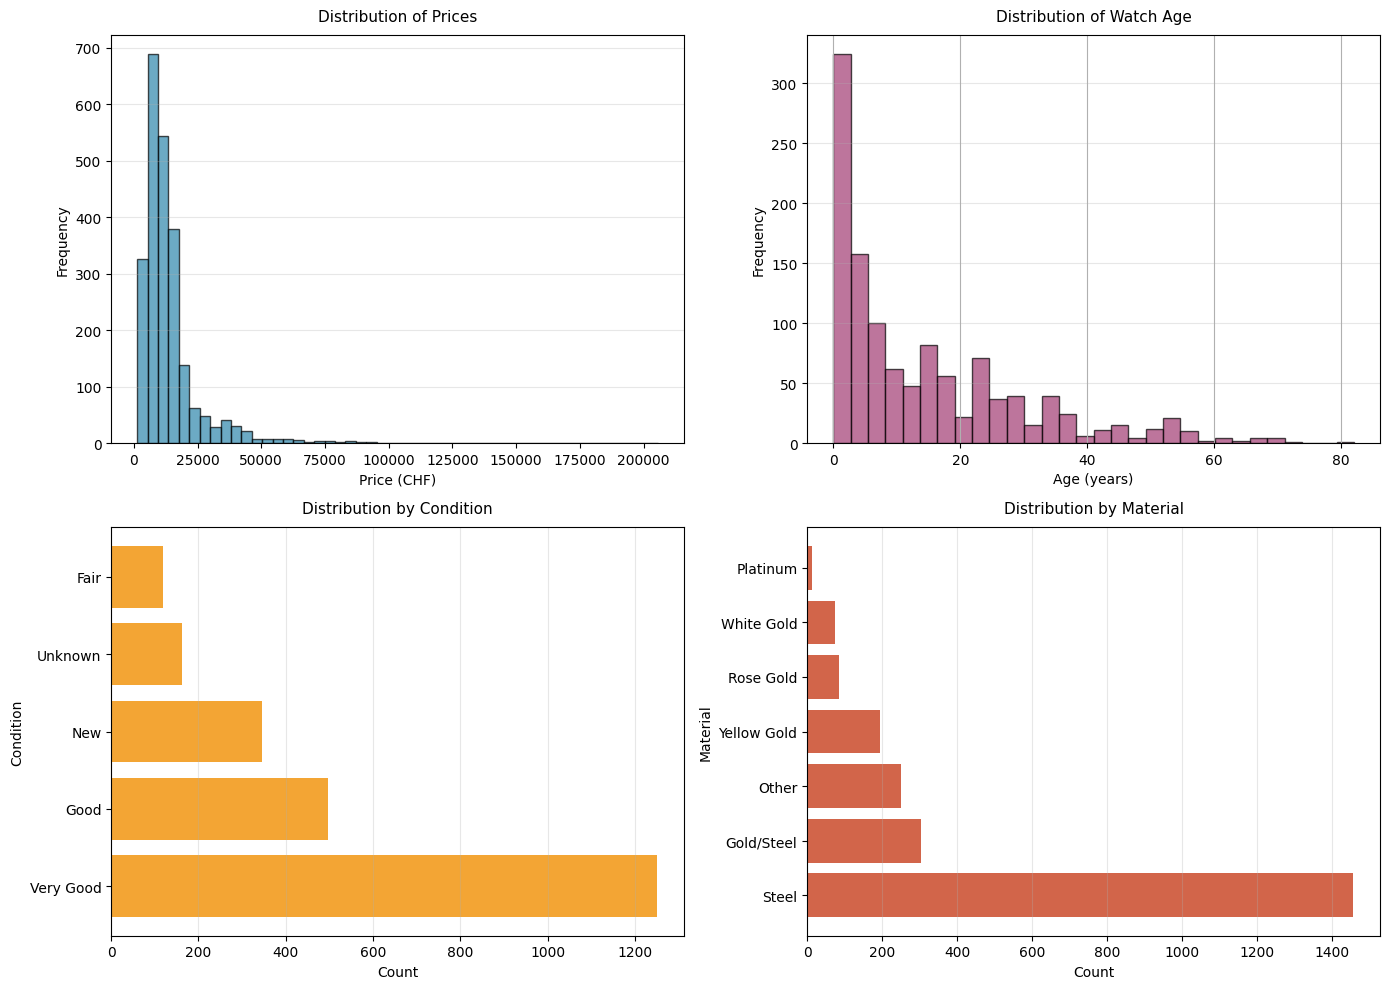

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_clean['price'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price (CHF)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Distribution of Prices', fontsize=11, pad=10)
axes[0, 0].grid(axis='y', alpha=0.3)

df_clean['age'].dropna().hist(bins=30, ax=axes[0, 1], color='#A23B72', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age (years)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Distribution of Watch Age', fontsize=11, pad=10)
axes[0, 1].grid(axis='y', alpha=0.3)

condition_counts = df_clean['condition_category'].value_counts()
axes[1, 0].barh(condition_counts.index, condition_counts.values, color='#F18F01', alpha=0.8)
axes[1, 0].set_xlabel('Count', fontsize=10)
axes[1, 0].set_ylabel('Condition', fontsize=10)
axes[1, 0].set_title('Distribution by Condition', fontsize=11, pad=10)
axes[1, 0].grid(axis='x', alpha=0.3)

material_counts = df_clean['material_category'].value_counts()
axes[1, 1].barh(material_counts.index, material_counts.values, color='#C73E1D', alpha=0.8)
axes[1, 1].set_xlabel('Count', fontsize=10)
axes[1, 1].set_ylabel('Material', fontsize=10)
axes[1, 1].set_title('Distribution by Material', fontsize=11, pad=10)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [54]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-28 11:30:54
Python Version: 3.11.13
-----------------------------------
